# Setup


In [9]:
%pip install ipywidgets
%pip install duckdb
%pip install matplotlib
%pip install seaborn
%pip install scipy
%matplotlib inline

import sys
sys.path.append('../scripts')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import duckdb

In [3]:
def load_features(dataset: str = "stackoverflow_dba", version: str = "v1.0", sqlstorm: bool = True):
    file = f"features/{version}/{dataset}{'_sqlstorm' if sqlstorm else ''}.csv.gz"
    features = duckdb.read_csv(file)
    operators = duckdb.read_csv(file.replace(".csv.gz", "_operators.csv.gz"))
    expressions = duckdb.read_csv(file.replace(".csv.gz", "_expressions.csv.gz"))

    operators2 = duckdb.sql("select query, operator from operators where operator <> 'Result' and operator <> 'GroupJoin' and operator <> 'Map' and operator <> 'IterationScan' and operator <> 'InlineTable'"
                            "union all select query, 'Join' as operator from operators where operator = 'GroupJoin'"
                            "union all select query, 'GroupBy' as operator from operators where operator = 'GroupJoin'")
    expressions2 = duckdb.sql("select query, expression, category, type from expressions where category <> 'base'")

    return features, operators2, expressions2

In [4]:
stackoverflow_v1, _, _ = load_features(dataset="stackoverflow_dba", version="v2.1", sqlstorm=True)
stackoverflow_v2, _, _ = load_features(dataset="stackoverflow_dba", version="v2.0", sqlstorm=True)

In [9]:
query_parts = []
for name in [
    "stackoverflow_v1",
    "stackoverflow_v2"
]:
    query_parts.append(f"""
select '{name}' as dataset, *, allocatedBytes as memory
from {name}
where state <> 'fatal' and state <> 'timeout' 
--and (replace(query, '.sql', '')::int <= 1000)
                  """)

data = duckdb.sql("union all ".join(query_parts))

duckdb.sql("""
select dataset, count(*), count(*) filter (where rows > 0) as nonzero,
           min(time), median(time), max(time), avg(time), min(memory), 
           median(memory), max(memory), avg(memory), max(memory)/1024/1024/1024 as memoryGB,
           min(ops), median(ops), max(ops), avg(ops),
           min(iterations), median(iterations), max(iterations), avg(iterations)
from data d
group by dataset,
order by dataset
""").show()

duckdb.sql("""select * from data limit 1""").show()

┌──────────────────┬──────────────┬─────────┬─────────────┬────────────────┬─────────────┬────────────────────┬─────────────┬────────────────┬────────────────┬────────────────────┬────────────────────┬──────────┬─────────────┬──────────┬────────────────────┬─────────────────┬────────────────────┬─────────────────┬──────────────────────┐
│     dataset      │ count_star() │ nonzero │ min("time") │ median("time") │ max("time") │    avg("time")     │ min(memory) │ median(memory) │  max(memory)   │    avg(memory)     │      memoryGB      │ min(ops) │ median(ops) │ max(ops) │      avg(ops)      │ min(iterations) │ median(iterations) │ max(iterations) │   avg(iterations)    │
│     varchar      │    int64     │  int64  │   double    │     double     │   double    │       double       │   double    │     double     │     double     │       double       │       double       │  double  │   double    │  double  │       double       │     double      │       double       │     double      │       

In [6]:
import numpy as np
import scipy.stats as stats


def get_density_log(dataset, column="time", min_x=0.5, max_x=600000):
    values = [x[0] for x in duckdb.sql(f"""
select {column}
from data
where dataset = '{dataset}' and {column} > 0
""").fetchall()]
    xmin, xmax = np.min(values), np.max(values)
    log_values = np.log10(values)
    density = stats.gaussian_kde(log_values, bw_method=0.1)

    x_vals = np.linspace(np.log10(min_x), np.log10(max_x), 1000)
    y_vals = density(x_vals)

    hist_y, _ = np.histogram(log_values, bins=x_vals, density=True)

    y_sum = np.sum(y_vals)
    y_vals = [float(y / y_sum) for y in y_vals]
    x_vals = [float(10 ** x) for x in x_vals]

    hist_y_sum = np.sum(hist_y)
    hist_y = [float(y / hist_y_sum) for y in hist_y]
    hist_y.append(hist_y[-1])

    print(xmin, xmax)
    y_vals = [y for i, y in enumerate(y_vals) if xmin <= x_vals[i] <= xmax]
    x_vals = [x for x in x_vals if xmin <= x <= xmax]

    return x_vals, y_vals, -np.max(y_vals) / 20, np.max(y_vals) * 1.1, hist_y, values


def get_density(dataset, column="time", min_x=0.5, max_x=600000):
    values = [x[0] for x in duckdb.sql(f"""
select {column}
from data
where dataset = '{dataset}' and {column} > 0
""").fetchall()]
    xmin, xmax = np.min(values), np.max(values)
    density = stats.gaussian_kde(values, bw_method=0.1)

    x_vals = np.linspace(min_x, max_x, 1000)
    y_vals = density(x_vals)

    hist_y, _ = np.histogram(values, bins=x_vals, density=True)

    y_sum = np.sum(y_vals)
    y_vals = [float(y / y_sum) for y in y_vals]

    hist_y_sum = np.sum(hist_y)
    hist_y = [float(y / hist_y_sum) for y in hist_y]
    hist_y.append(hist_y[-1])

    print(xmin, xmax)
    y_vals = [y for i, y in enumerate(y_vals) if xmin <= x_vals[i] <= xmax]
    x_vals = [x for x in x_vals if xmin <= x <= xmax]

    return x_vals, y_vals, -np.max(y_vals) / 20, np.max(y_vals) * 1.1, hist_y, values


time_v1 = get_density_log("stackoverflow_v1", column="time", min_x=0.4, max_x=100000)
time_v2 = get_density_log("stackoverflow_v2", column="time", min_x=0.4, max_x=100000)
memory_v1 = get_density_log("stackoverflow_v1", column="memory", min_x=512*1024, max_x=200*1024*1024*1024)
memory_v2 = get_density_log("stackoverflow_v2", column="memory", min_x=512*1024, max_x=200*1024*1024*1024)
ops_v1 = get_density("stackoverflow_v1", column="ops", min_x=1, max_x=255)
ops_v2 = get_density("stackoverflow_v2", column="ops", min_x=1, max_x=255)

0.576 51113.941
0.645 64917.417
655360.0 211289571328.0
655360.0 161803796480.0
1.0 33.0
1.0 255.0


0.5809788089326471
0.6498159724143207
1.0
1.0


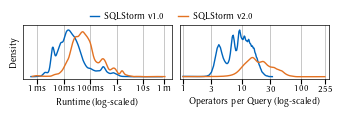

In [11]:
from plot.color import Color
from plot.linestyle import Linestyle
from plot.location import Location
from plot.formatter import Decorator, Grid, LambdaFormatter, NumberFormatter, Scale
from plot.lineplot import LinePlot
from plot.frame import Format, GridFrame, SingleFrame, cm2inch, latexify

densities = [time_v1, time_v2,]
mi = min([d[2] for d in densities])
ma = max([d[3] for d in densities])


def format_time(x):
    if x < 1000:
        return f"{int(x)}\\,ms"
    elif x < 60000:
        return f"{int(x / 1000)}\\,s"
    else:
        return f"{int(x / 60000)}\\,m"


latexify(hyperref=False, increase_font=-1)
frame = GridFrame(width=3.3, height=0.9, n_rows=1, n_columns=2)
plot = LinePlot(frame[0, 0], linewidth=1)
plot.format_axes(yformatter=NumberFormatter(scale=Scale.LINEAR, min=mi, max=ma, grid=Grid.MAJOR, decorator=Decorator.AXISLABEL, ticks=[], label="Density"),
                 xformatter=LambdaFormatter(format_time, scale=Scale.LOG, ticks=[1, 10, 100, 1000, 10000, 60000, 600000], min=0.3, max=120000, label="Runtime (log-scaled)"))
# plot.ax.yaxis.set_label_coords(1, 0.5)

colors = [Color.TUMBLUE, Color.TUMORANGE]
linestyles = [Linestyle.SOLID, Linestyle.SOLID]
handles = []
for i, density in enumerate(densities):
    print(min(density[0]))
    handles.append(plot.plot(x=density[0], y=density[1], color=colors[i], linestyle=linestyles[i]))

h1 = handles[0]
h2 = handles[1]
# frame.legend([h3, h4, h5], ["StackOverflow", "Redset", "Snowset"], bbox_to_anchor=(0.5, 1.125), location=Location.CENTER, columns=3)
# frame.legend([h1, h2], ["TPC-H (220GB)", "TPC-DS (220GB)"], bbox_to_anchor=(0.5, 1.025), location=Location.CENTER, columns=2)

densities = [ops_v1, ops_v2]
mi = min([d[2] for d in densities])
ma = max([d[3] for d in densities])


def format_ops(x):
    return x


plot = LinePlot(frame[0, 1], linewidth=1)
plot.format_axes(yformatter=NumberFormatter(scale=Scale.LINEAR, min=mi, max=ma, grid=Grid.MAJOR, decorator=Decorator.NONE, ticks=[], label="Density"),
                 xformatter=LambdaFormatter(format_ops, scale=Scale.LOG, ticks=[1, 3, 10, 30, 100, 255], min=0.9, max=300, label="Operators per Query (log-scaled)"))
# plot.ax.yaxis.set_label_coords(1, 0.5)

handles = []
for i, density in enumerate(densities):
    print(min(density[0]))
    handles.append(plot.plot(x=density[0], y=density[1], color=colors[i], linestyle=linestyles[i]))

h1 = handles[0]
h2 = handles[1]

frame.legend([h1, h2], ["SQLStorm v1.0", "SQLStorm v2.0"], bbox_to_anchor=(0.5, 1.05), location=Location.CENTER, columns=2)

file = "pdf/v1_v2_density"
frame.save(file, format=Format.PDF)

661749.3452638129
661749.3452638129


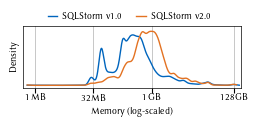

In [ ]:
densities = [memory_v1, memory_v2]
mi = min([d[2] for d in densities])
ma = max([d[3] for d in densities])


def format_memory(x):
    if x < 1024:
        return f"{int(x)}\\,B"
    elif x < 1024*1024:
        return f"{int(x / 1024)}\\,KB"
    elif x < 1024*1024*1024:
        return f"{int(x / (1024*1024))}\\,MB"
    elif x < 1024*1024*1024*1024:
        return f"{int(x / (1024*1024*1024))}\\,GB"
    else:
        return f"{int(x / (1024*1024*1024*1024))}\\,TB"


latexify(hyperref=False, increase_font=-1)
frame = SingleFrame(width=cm2inch(6.25), height=cm2inch(2.5))
plot = LinePlot(frame, linewidth=1)
plot.format_axes(yformatter=NumberFormatter(scale=Scale.LINEAR, min=mi, max=ma, grid=Grid.MAJOR, decorator=Decorator.AXISLABEL, ticks=[], label="Density"),
                 xformatter=LambdaFormatter(format_memory, scale=Scale.LOG, ticks=[2**20, 2**25, 2**30, 2**37], min=512*1024, max=200*1024*1024*1024, label="Memory (log-scaled)"))
# plot.ax.yaxis.set_label_coords(1, 0.5)

colors = [Color.TUMBLUE, Color.TUMORANGE]
linestyles = [Linestyle.SOLID, Linestyle.SOLID]
handles = []
for i, density in enumerate(densities):
    print(min(density[0]))
    handles.append(plot.plot(x=density[0], y=density[1], color=colors[i], linestyle=linestyles[i]))

h1 = handles[0]
h2 = handles[1]

frame.legend([h1, h2], ["SQLStorm v1.0", "SQLStorm v2.0"], bbox_to_anchor=(0.5, 1.05), location=Location.CENTER, columns=2)

file = "analysis/memory_density"
frame.save(file, format=Format.PDF)

1.0
1.0


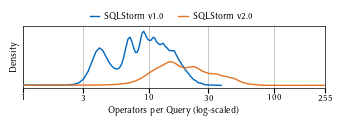

In [ ]:
densities = [ops_v1, ops_v2]
mi = min([d[2] for d in densities])
ma = max([d[3] for d in densities])


def format_ops(x):
    return x


latexify(hyperref=False, increase_font=-1)
frame = SingleFrame(width=3.3, height=cm2inch(2.5))
plot = LinePlot(frame, linewidth=1)
plot.format_axes(yformatter=NumberFormatter(scale=Scale.LINEAR, min=mi, max=ma, grid=Grid.MAJOR, decorator=Decorator.AXISLABEL, ticks=[], label="Density"),
                 xformatter=LambdaFormatter(format_ops, scale=Scale.LOG, ticks=[1, 3, 10, 30, 100, 255], min=1, max=255, label="Operators per Query (log-scaled)"))
# plot.ax.yaxis.set_label_coords(1, 0.5)

colors = [Color.TUMBLUE, Color.TUMORANGE]
linestyles = [Linestyle.SOLID, Linestyle.SOLID]
handles = []
for i, density in enumerate(densities):
    print(min(density[0]))
    handles.append(plot.plot(x=density[0], y=density[1], color=colors[i], linestyle=linestyles[i]))

h1 = handles[0]
h2 = handles[1]

frame.legend([h1, h2], ["SQLStorm v1.0", "SQLStorm v2.0"], bbox_to_anchor=(0.5, 1.05), location=Location.CENTER, columns=2)

file = "analysis/ops_density"
frame.save(file, format=Format.PDF)